# TP2 ACP — Analyse en Composantes Principales Normée


## Imports et données

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from numpy import linalg as LA
import numpy as np

np.set_printoptions(precision=4, suppress=True)

# Matrice X (20 villes, 6 sports)
X = np.array([
    [1881.9, 96.8, 14.2, 25.2, 1135.5, 278.3],
    [3369.8, 96.8, 10.8, 51.6, 1331.7, 284.0],
    [4467.4, 138.2, 9.5, 34.2, 2346.1, 312.3],
    [1862.1, 83.2, 8.8, 27.6, 972.6, 203.4],
    [3499.8, 287.0, 11.5, 49.4, 2139.4, 358.0],
    [3903.2, 170.7, 6.3, 42.0, 1935.2, 292.9],
    [2620.7, 129.5, 4.2, 16.8, 1346.0, 131.8],
    [3678.4, 157.0, 6.0, 24.9, 1682.6, 194.2],
    [3840.5, 187.9, 10.2, 39.6, 1859.9, 449.1],
    [2170.2, 140.5, 11.7, 31.1, 1351.1, 256.5],
    [3920.4, 128.0, 7.2, 25.5, 1911.5, 64.1],
    [2599.6, 39.6, 5.5, 19.4, 1050.8, 172.5],
    [2828.5, 211.3, 9.9, 21.8, 1085.0, 209.0],
    [2498.7, 123.2, 7.4, 26.5, 1086.2, 153.5],
    [2685.1, 41.2, 2.3, 10.6, 812.5, 89.8],
    [2739.3, 100.7, 6.6, 22.0, 1270.4, 180.5],
    [1662.1, 81.1, 10.1, 19.1, 872.2, 123.3],
    [2469.9, 142.9, 15.5, 30.9, 1165.5, 335.5],
    [2350.7, 38.7, 2.4, 13.5, 1253.1, 170.0],
    [3177.7, 292.1, 8.0, 34.8, 1400.0, 358.9]
])

m, p = X.shape  # m=20 individus, p=6 variables
print("Dimensions de X :", X.shape)

Dimensions de X : (20, 6)


## — Centre de gravité (individu moyen)

On calcule le vecteur des moyennes de chaque variable.

In [19]:
# calcule le centre de gravite
def calcule_Centre(m):
    g = np.zeros(len(m[0]))
    for i in range(len(g)):
        g[i] = np.mean(m[:, i])
    return g

vect_g = calcule_Centre(X)
print('le centre de gravite = ', vect_g)

le centre de gravite =  [2911.3    134.32     8.405   28.325 1400.365  230.88 ]


## Matrice centrée Y

On soustrait le centre de gravité à chaque ligne de X.

In [20]:
#matrice centree
#d'abord on commence par calcule la matrice centree:
def matrice_centree(m):
    vec_g = calcule_Centre(m)
    c = np.zeros(m.shape)
    for i in range(len(m)):
        for j in range(len(m[i])):
            c[i][j] = m[i][j] - vec_g[j]
    return c

Y = matrice_centree(X)
print("matrice centree Y =\n", Y)

matrice centree Y =
 [[-1029.4     -37.52      5.795    -3.125  -264.865    47.42 ]
 [  458.5     -37.52      2.395    23.275   -68.665    53.12 ]
 [ 1556.1       3.88      1.095     5.875   945.735    81.42 ]
 [-1049.2     -51.12      0.395    -0.725  -427.765   -27.48 ]
 [  588.5     152.68      3.095    21.075   739.035   127.12 ]
 [  991.9      36.38     -2.105    13.675   534.835    62.02 ]
 [ -290.6      -4.82     -4.205   -11.525   -54.365   -99.08 ]
 [  767.1      22.68     -2.405    -3.425   282.235   -36.68 ]
 [  929.2      53.58      1.795    11.275   459.535   218.22 ]
 [ -741.1       6.18      3.295     2.775   -49.265    25.62 ]
 [ 1009.1      -6.32     -1.205    -2.825   511.135  -166.78 ]
 [ -311.7     -94.72     -2.905    -8.925  -349.565   -58.38 ]
 [  -82.8      76.98      1.495    -6.525  -315.365   -21.88 ]
 [ -412.6     -11.12     -1.005    -1.825  -314.165   -77.38 ]
 [ -226.2     -93.12     -6.105   -17.725  -587.865  -141.08 ]
 [ -172.      -33.62     -1.805   

## Écart-type (population)

On calcule l'écart-type de chaque variable (formule de population, diviseur = m).

In [21]:
# calcule l'ecart type
def ecart_type(m):
    ecartype = np.zeros(len(m[0]))
    for i in range(len(m[0])):
        ecartype[i] = np.std(m[:, i])
    return ecartype

ecartype = ecart_type(X)
ecartype

array([765.5634,  69.0405,   3.4302,  10.8126, 423.1189,  98.6523])

## Matrice centrée réduite Z

On divise chaque colonne de Y par l'écart-type correspondant.

In [22]:
def matrice_centree_reduite(m):
    mcr = np.zeros(m.shape)
    etp = ecart_type(X)
    for i in range(len(m)):
        for j in range(len(m[i])):
            mcr[i][j] = m[i][j] / etp[j]
    return mcr

Z = matrice_centree_reduite(Y)
print("matrice centre reduite Z =\n ", Z)

matrice centre reduite Z =
  [[-1.3446 -0.5434  1.6894 -0.289  -0.626   0.4807]
 [ 0.5989 -0.5434  0.6982  2.1526 -0.1623  0.5385]
 [ 2.0326  0.0562  0.3192  0.5433  2.2352  0.8253]
 [-1.3705 -0.7404  0.1152 -0.0671 -1.011  -0.2786]
 [ 0.7687  2.2115  0.9023  1.9491  1.7466  1.2886]
 [ 1.2956  0.5269 -0.6137  1.2647  1.264   0.6287]
 [-0.3796 -0.0698 -1.2259 -1.0659 -0.1285 -1.0043]
 [ 1.002   0.3285 -0.7011 -0.3168  0.667  -0.3718]
 [ 1.2137  0.7761  0.5233  1.0428  1.0861  2.212 ]
 [-0.968   0.0895  0.9606  0.2566 -0.1164  0.2597]
 [ 1.3181 -0.0915 -0.3513 -0.2613  1.208  -1.6906]
 [-0.4072 -1.3719 -0.8469 -0.8254 -0.8262 -0.5918]
 [-0.1082  1.115   0.4358 -0.6035 -0.7453 -0.2218]
 [-0.5389 -0.1611 -0.293  -0.1688 -0.7425 -0.7844]
 [-0.2955 -1.3488 -1.7798 -1.6393 -1.3894 -1.4301]
 [-0.2247 -0.487  -0.5262 -0.585  -0.3072 -0.5107]
 [-1.6317 -0.7709  0.4941 -0.8532 -1.2483 -1.0905]
 [-0.5766  0.1243  2.0684  0.2381 -0.5551  1.0605]
 [-0.7323 -1.385  -1.7506 -1.3711 -0.348  -0.6171]
 [

## Matrice de corrélation R

R = (1/m) × Zᵗ × Z

In [23]:
# matrice de coorelation
def calcule_correlation(m):
    return ((1/len(m)) * (np.matmul(np.transpose(m), m)))

R = calcule_correlation(Z)
print('matrice de correlation = \n', R)

matrice de correlation = 
 [[ 1.      0.4518 -0.1059  0.5173  0.8651  0.3525]
 [ 0.4518  1.      0.3535  0.5904  0.53    0.6192]
 [-0.1059  0.3535  1.      0.5344  0.101   0.5859]
 [ 0.5173  0.5904  0.5344  1.      0.5977  0.7501]
 [ 0.8651  0.53    0.101   0.5977  1.      0.468 ]
 [ 0.3525  0.6192  0.5859  0.7501  0.468   1.    ]]


On peut aussi afficher la matrice triangulaire supérieure (np.triu) pour mieux lire les corrélations :

In [24]:
corr = np.triu(R)
corr

array([[ 1.    ,  0.4518, -0.1059,  0.5173,  0.8651,  0.3525],
       [ 0.    ,  1.    ,  0.3535,  0.5904,  0.53  ,  0.6192],
       [ 0.    ,  0.    ,  1.    ,  0.5344,  0.101 ,  0.5859],
       [ 0.    ,  0.    ,  0.    ,  1.    ,  0.5977,  0.7501],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  1.    ,  0.468 ],
       [ 0.    ,  0.    ,  0.    ,  0.    ,  0.    ,  1.    ]])

### Visualisation de la matrice de corrélation (Heatmap)

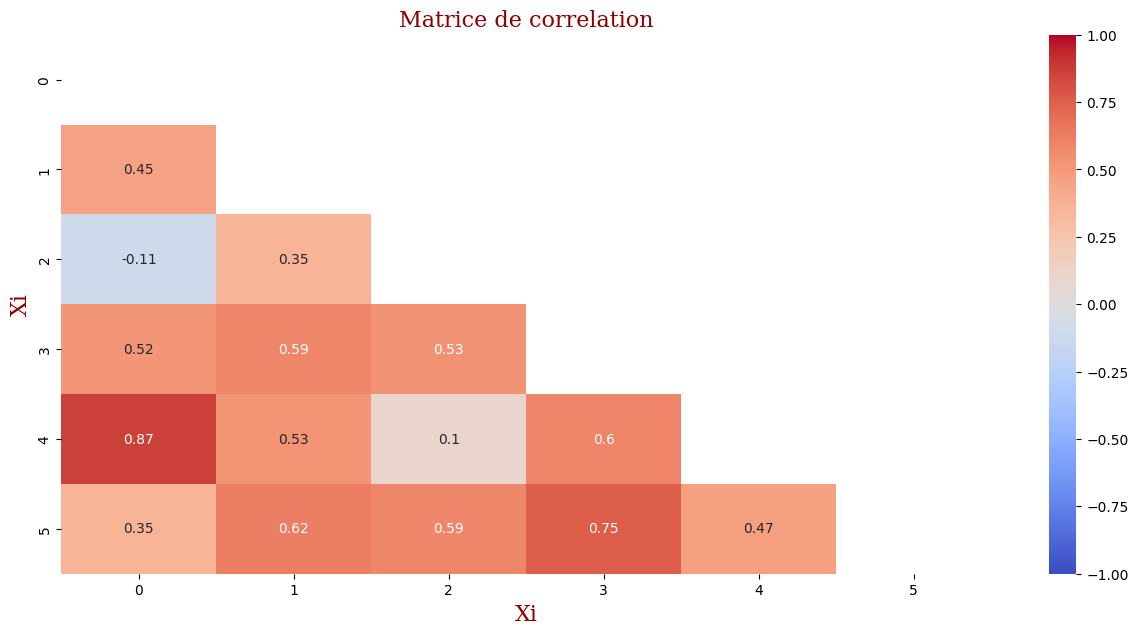

In [25]:
#La police utilisée
font = {'family': 'serif',
        'color': 'darkred',
        'weight': 'normal',
        'size': 16,
        }

#la taille de la figure
plt.figure(figsize=(15, 7))
#le titre
plt.title("Matrice de correlation", fontdict=font)
#la representation
sns.heatmap(R, vmax=1, vmin=-1, annot=True, cmap='coolwarm', mask=corr)
#Le titre des axes
plt.xlabel('Xi', fontdict=font)
plt.ylabel('Xi', fontdict=font)
plt.show()

## Question 1 — Valeurs propres et vecteurs propres

**Matrice utilisée :** la matrice de corrélation R (dimension p×p = 6×6).

On utilise `LA.eig(R)` de numpy.linalg pour calculer la décomposition spectrale.

In [26]:
# determination des valeurs propres et les vecteurs propres
valp, vecp = LA.eig(R)
print('les valeurs propres :\n', valp)

les valeurs propres :
 [3.4859 1.4219 0.4728 0.1064 0.2943 0.2187]


In [27]:
print('les vecteurs propres :\n', vecp.T)

les vecteurs propres :
 [[-0.3767 -0.4219 -0.2684 -0.4741 -0.4298 -0.4457]
 [-0.5533  0.0451  0.6489  0.1349 -0.412   0.288 ]
 [-0.1686  0.8757 -0.2686 -0.3014 -0.2044 -0.007 ]
 [ 0.7194  0.0098  0.2317 -0.1488 -0.6374  0.0163]
 [-0.0664 -0.1854 -0.5988  0.2447 -0.3358  0.6557]
 [ 0.0412 -0.1369  0.1501 -0.7643  0.291   0.5368]]


## Question 2 — Vérification : A·v = λ·v

Un vecteur v est vecteur propre de A associé à λ si et seulement si **A·v = λ·v**.

In [28]:
# Verification: R * vi = lambda_i * vi
def verif_vp(A, v, lam, tol=1e-6):
    return np.allclose(A @ v, lam * v, atol=tol)

# Test sur le 1er vecteur propre
v1 = vecp.T[0]
lambda1 = valp[0]
print("v1 est-il vecteur propre de R associe a lambda1 ?", verif_vp(R, v1, lambda1))

# Affichage numerique
print("\nR * v1 =", np.round(R @ v1, 4))
print("lambda1 * v1 =", np.round(lambda1 * v1, 4))

v1 est-il vecteur propre de R associe a lambda1 ? True

R * v1 = [-1.3131 -1.4705 -0.9355 -1.6526 -1.4983 -1.5537]
lambda1 * v1 = [-1.3131 -1.4705 -0.9355 -1.6526 -1.4983 -1.5537]


## Question 3 — Graphe des valeurs propres (Éboulis)

Le graphe des valeurs propres (scree plot) permet d'identifier le "coude" pour choisir le nombre d'axes à retenir.

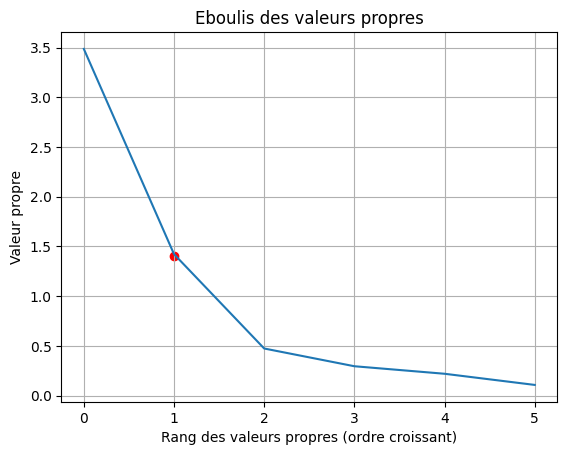

In [38]:
# representation graphique des valeurs propres
plt.plot(sorted(valp, reverse=True))
plt.scatter(1,1.4, color = "r")
plt.xlabel("Rang des valeurs propres (ordre croissant)")
plt.ylabel("Valeur propre")
plt.title("Eboulis des valeurs propres")
plt.grid()
plt.show()

**Analyse :** Le graphe montre une chute brutale après les 2 premières valeurs propres (λ1 ≈ 3.49, λ2 ≈ 1.42). C'est le "coude" caractéristique qui indique qu'on doit retenir **2 axes**.

## Question 4 — Tableau : valeurs propres, taux d'inertie, taux cumulés

In [30]:
# Trier les valeurs propres par ordre décroissant
valp_sorted = np.sort(valp)[::-1]

# Calcul de la variance expliquée
variance_expliquee = valp_sorted / np.sum(valp_sorted)

# Variance cumulée
variance_cumulee = np.cumsum(variance_expliquee)

print("Valeurs propres triées :\n", valp_sorted)
print("\nVariance expliquée (%) :\n", variance_expliquee * 100)
print("\nVariance cumulée (%) :\n", variance_cumulee * 100)

print("\nAxe | Valeur propre | Taux d'inertie (%) | Taux cumulé (%)")
print("-" * 60)
for i in range(p):
    print(f"{i+1:3d} | {valp_sorted[i]:12.4f} | {variance_expliquee[i]:16.2f} | {variance_cumulee[i]:14.2f}")


# Détermination du nombre d'axes pour atteindre 80%
nb_axes = np.argmax(variance_cumulee >= 0.80) + 1

print("\nNombre d'axes à retenir (>= 80%) :", nb_axes)

#lambda 1 + lambda 2 / somme des lambda = 81.7 >80 donc 2 axe sont suffisant

Valeurs propres triées :
 [3.4859 1.4219 0.4728 0.2943 0.2187 0.1064]

Variance expliquée (%) :
 [58.0988 23.6976  7.8797  4.9056  3.6444  1.7738]

Variance cumulée (%) :
 [ 58.0988  81.7964  89.6761  94.5817  98.2262 100.    ]

Axe | Valeur propre | Taux d'inertie (%) | Taux cumulé (%)
------------------------------------------------------------
  1 |       3.4859 |             0.58 |           0.58
  2 |       1.4219 |             0.24 |           0.82
  3 |       0.4728 |             0.08 |           0.90
  4 |       0.2943 |             0.05 |           0.95
  5 |       0.2187 |             0.04 |           0.98
  6 |       0.1064 |             0.02 |           1.00

Nombre d'axes à retenir (>= 80%) : 2


**Instruction `np.cumsum()` :** calcule la somme cumulée. Elle permet de savoir combien de variance totale est capturée en gardant k axes. Par exemple, 2 axes capturent 81.8% de la variance totale, ce qui est suffisant.

 **Remarque**

**A** partir de ces taux calculés, nous pouvons déduire la dimension du meilleur sous espace
 ajustant le nuage des individus. Le premier axe principal associé à la plus grande valeur
 propre recouvre plus que 58.09 % de l’inertie totale cad 58.09% de l'information reside sur cette axe. D’autre part, nous remarquons que le taux d’inertie expliqué par les deux
 premiers axes est égal à (lambda 1 + lambda 2
) c'est à dire à 81.79% , et donc ça serait obligatoire de
 le prendre aussi (selon le critère de % d'inertie).
 * Ce qui explique de déterminer le sous espace de dimension 2 ajustant le nuage de points. Pour déterminer ces deux axe, nous calculons les deux vecteurs propres normés associé aux deux grandes valeurs propres.

## Question 5 — Choix de la dimension du sous-espace

**On retient 2 axes (F1 et F2).**

- **Critère de Kaiser** : on garde les axes avec λ > 1 → F1 (λ≈3.49) et F2 (λ≈1.42)
- **Critère du coude** : cassure nette dans l'éboulis après F2
- **Taux cumulé** : F1+F2 = 81.8% ≥ 80% ✓

λ1 + λ2 / somme des λ = 81.7% > 80%, donc **2 axes sont suffisants**.

![image.png](image.png)

In [39]:
#Les composantes principales associées aux axes déterminés
C1 = np.matmul(Z, u1)
C2 = np.matmul(Z, u2)
print('C1 = ', C1)
print()
print('C2 = ', C2)
#Ces deux composantes représentent les deux nouvelles variables

C1 =  [ 0.4742 -1.3744 -2.4612  1.3882 -3.7137 -1.9687  1.5096 -0.2987 -2.8721
 -0.1183 -0.0055  1.9696  0.1587  1.0983  3.1696  1.0682  2.2342 -0.7373
  2.4045 -1.9254]

C2 =  [ 2.1729  0.6095 -1.5247  1.1268  0.1744 -1.2603 -0.9687 -1.4191  0.0333
  1.3203 -1.981  -0.3276  0.5547  0.158  -1.1128 -0.3385  1.2737  2.2329
 -1.0126  0.2888]


## Question 6 — Axes factoriels retenus

Les axes factoriels sont les vecteurs propres associés aux plus grandes valeurs propres. On les affiche dans un tableau.

In [31]:
u1 = vecp.T[0]
print("vecteur propre u1 = ", u1)
print()
u2 = vecp.T[1]
print("vecteur propre u2 = ", u2)

vecteur propre u1 =  [-0.3767 -0.4219 -0.2684 -0.4741 -0.4298 -0.4457]

vecteur propre u2 =  [-0.5533  0.0451  0.6489  0.1349 -0.412   0.288 ]


In [41]:
# vérifier que les deux vecteurs sont de norme 1

norme_u1 = np.sqrt((u1[0]**2 + u1[1]**2 + u1[2]**2)+u1[3]**2+ u1[4]**2 + u1[5]**2 )
print(norme_u1)
print()
norme_u2 = np.sqrt((u2[0]**2 + u2[1]**2 + u2[2]**2) + u1[3]**2 + u1[4]**2 + u1[5]**2)
print(norme_u2)

0.9999999999999999

1.1564212804507759


In [40]:
import pandas as pd

sports = ["Handball", "Basketball", "Tennis", "Gym", "Natation", "Football"]

# Valeurs propres et vecteurs propres (triés par ordre décroissant)
# valp  = tableau des valeurs propres
# vecp  = matrice des vecteurs propres (vecteurs en COLONNES)

# utiliser [:, i] pour prendre la i-ème colonne
fi1 = np.sqrt(valp[0]) * vecp[:, 0]
fi2 = np.sqrt(valp[1]) * vecp[:, 1]


# Affichage en tableau
df_fi = pd.DataFrame({
    "fi1 = corr(Xj, C1)": fi1.round(4),
    "fi2 = corr(Xj, C2)": fi2.round(4)}, index=sports)

print(df_fi.to_string())

            fi1 = corr(Xj, C1)  fi2 = corr(Xj, C2)
Handball               -0.7033             -0.6597
Basketball             -0.7876              0.0538
Tennis                 -0.5010              0.7737
Gym                    -0.8851              0.1609
Natation               -0.8025             -0.4912
Football               -0.8322              0.3434


## Question 7 — Projections des individus

Les coordonnées factorielles (projections) des individus sont calculées par : **C = Z × U**

Où Z est la matrice centrée réduite et U la matrice des vecteurs propres retenus (colonnes F1, F2).

In [33]:
# Projections des individus sur les 2 premiers axes
U12 = np.column_stack([vecp.T[0], vecp.T[1]])  # matrice 6x2
coord = Z @ U12  # projections : matrice 20x2

print("Coordonnées factorielles des individus (F1, F2) :")
print(f"{'Ville':<8} {'F1':>10} {'F2':>10}")
print("-" * 30)
for i in range(m):
    print(f"V{i+1:<7} {coord[i,0]:>10.4f} {coord[i,1]:>10.4f}")

Coordonnées factorielles des individus (F1, F2) :
Ville            F1         F2
------------------------------
V1           0.4742     2.1729
V2          -1.3744     0.6095
V3          -2.4612    -1.5247
V4           1.3882     1.1268
V5          -3.7137     0.1744
V6          -1.9687    -1.2603
V7           1.5096    -0.9687
V8          -0.2987    -1.4191
V9          -2.8721     0.0333
V10         -0.1183     1.3203
V11         -0.0055    -1.9810
V12          1.9696    -0.3276
V13          0.1587     0.5547
V14          1.0983     0.1580
V15          3.1696    -1.1128
V16          1.0682    -0.3385
V17          2.2342     1.2737
V18         -0.7373     2.2329
V19          2.4045    -1.0126
V20         -1.9254     0.2888


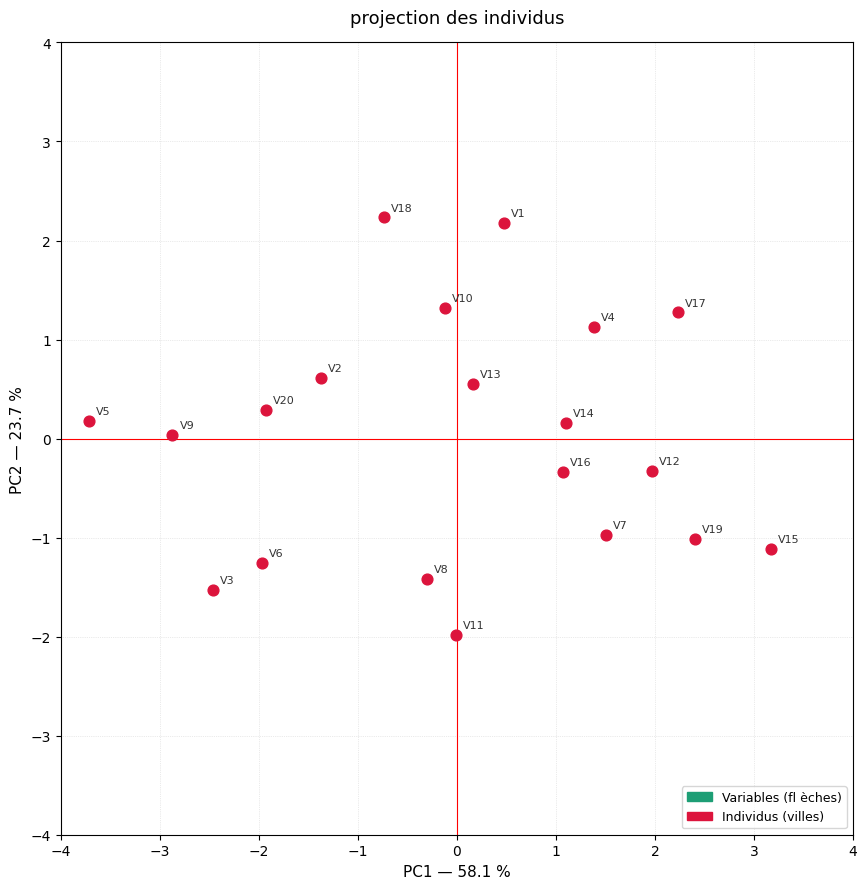

In [44]:
import matplotlib.patches as mpatches

sports   = ["Handball","Basketball","Tennis","Gym","Natation","Football"]
cities   = [f"V{i}" for i in range(1, 21)]


# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))

# --- axes rouges ---
ax.axhline(0, color='red', linewidth=0.8, linestyle='-')
ax.axvline(0, color='red', linewidth=0.8, linestyle='-')



# --- individus (villes) ---
ax.scatter(C1, C2, c='crimson', s=60, zorder=5, marker='o')
for i in range(len(C1)):
    ax.text(C1[i] + 0.07, C2[i] + 0.07,
            f"V{i+1}", fontsize=8, color='#333333')


# --- mise en forme ---
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.set_xlabel(f"PC1 — {round(valp[0]/valp.sum()*100, 1)} %", fontsize=11)
ax.set_ylabel(f"PC2 — {round(valp[1]/valp.sum()*100, 1)} %", fontsize=11)
ax.set_title("projection des individus", fontsize=13, pad=14)
ax.set_aspect('equal')
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)

# --- légende ---
var_patch = mpatches.Patch(color='#1D9E75', label='Variables (fl èches)')
ind_patch = mpatches.Patch(color='crimson',  label='Individus (villes)')
ax.legend(handles=[var_patch, ind_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

8) Interpréter les graphes obtenus. Analyser bien le nuage des variables.

➢ Les points les plus intéressants sont ceux qui sont proche de l’origine et les plus
proches d’un des axes. On dit que ces points sont bien représentés.

➢ Donc, notre intérêt sera focalisé sur ces points.

➢ Les villes (individus) v5,v9,v20 et v2  sont proches donc ils sont similaires


Pour les individus, les biens representées sont ceux qui sont loin de l'origne.

Pour les variables sont celles qui sont proche du perimetre. Celles qui sont proches de l'origines ne sont pas intérressants.

## Question 8 — Représentation graphique dans le plan factoriel (F1, F2)

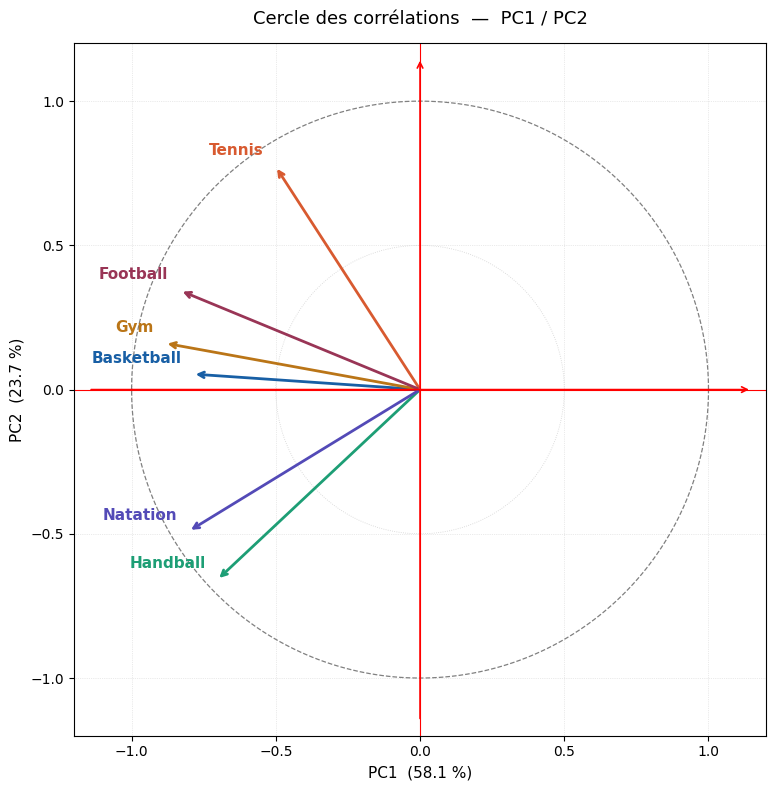

In [45]:

# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))

# --- cercle unité ---
an = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(an), np.sin(an), color='gray', linewidth=0.9, linestyle='--')

# --- cercle 0.5 ---
ax.plot(0.5 * np.cos(an), 0.5 * np.sin(an),
        color='lightgray', linewidth=0.6, linestyle=':')

# --- axes ---
ax.axhline(0, color='red', linewidth=0.8)
ax.axvline(0, color='red', linewidth=0.8)

# --- flèches + labels variables ---
colors_vars = ['#1D9E75','#185FA5','#D85A30','#BA7517','#534AB7','#993556']

for i in range(fi1.shape[0]):
    ax.annotate("",
                xy=(fi1[i], fi2[i]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors_vars[i], lw=2))

    offset_x = 0.04 if fi1[i] >= 0 else -0.04
    offset_y = 0.04
    ha = 'left' if fi1[i] >= 0 else 'right'

    ax.text(fi1[i] + offset_x, fi2[i] + offset_y,
            sports[i], fontsize=11, fontweight='bold',
            color=colors_vars[i], ha=ha)
# Axe horizontal avec flèche à droite
ax.annotate("", xy=(1.15, 0), xytext=(-1.15, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

# Axe vertical avec flèche en haut
ax.annotate("", xy=(0, 1.15), xytext=(0, -1.15),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
# --- mise en forme ---
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.set_xlabel(f"PC1  ({round(valp[0]/valp.sum()*100, 1)} %)", fontsize=11)
ax.set_ylabel(f"PC2  ({round(valp[1]/valp.sum()*100, 1)} %)", fontsize=11)
ax.set_title("Cercle des corrélations  —  PC1 / PC2", fontsize=13, pad=14)
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

Rmq 1,

toutes les variables orientées dans un seul sens. (ds notre cas, le coté negatif)

C’est-à-dire les variables sont correlees negativement au premier axe. Ensuite on cherche celles qui sont fortement ou bien faiblement corrélées.

on peut dire donc que : Gym, Hand ball, Natation et Basket sont fortement corrélé avec l'axe 1

Par rapport a l’axe 2 :

Tennis est fortement correlee a l’axe 2

Natation et handball sont corrélées negativement a l’axe 2 (opposés)

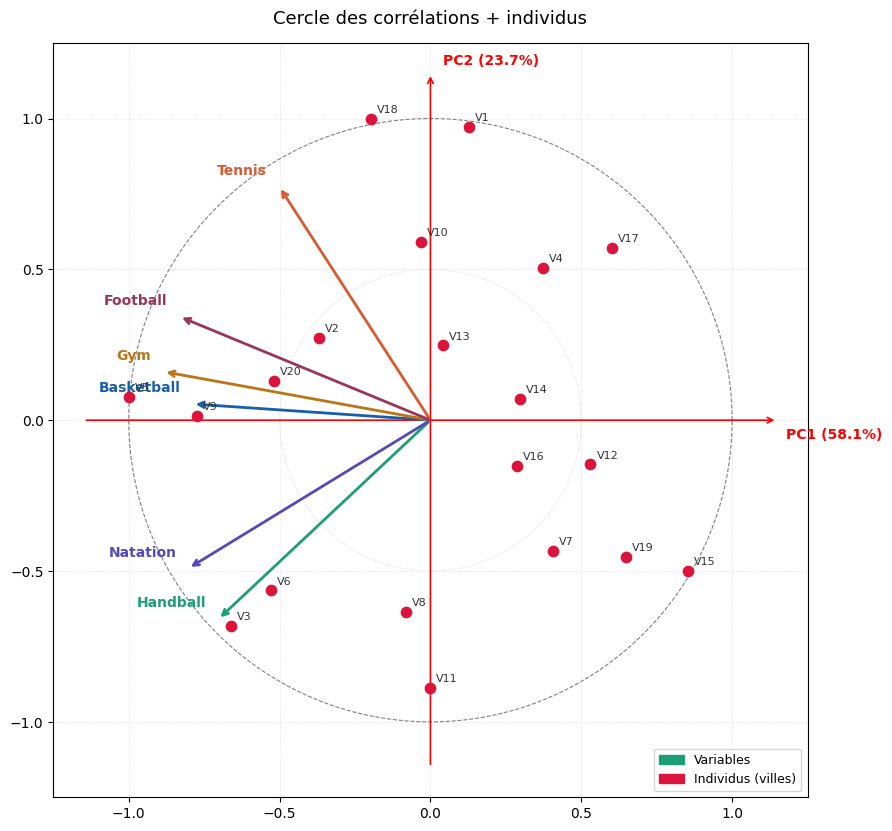

In [46]:


sports = ["Handball","Basketball","Tennis","Gym","Natation","Football"]
cities = [f"V{i}" for i in range(1, 21)]

# --- normalisés les individus---

C1_norm = C1 / np.max(np.abs(C1))
C2_norm = C2 / np.max(np.abs(C2))

# -------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 9))

# --- cercle unité ---
an = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(an), np.sin(an), color='gray', linewidth=0.8, linestyle='--')

# --- cercle 0.5 ---
ax.plot(0.5 * np.cos(an), 0.5 * np.sin(an),
        color='lightgray', linewidth=0.6, linestyle=':')

# --- axes avec flèches ---
ax.annotate("", xy=(1.15, 0), xytext=(-1.15, 0),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.2))
ax.annotate("", xy=(0, 1.15), xytext=(0, -1.15),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.2))

# --- labels axes ---
ax.text(1.18, -0.06,
        f"PC1 ({round(valp[0]/valp.sum()*100,1)}%)",
        fontsize=10, color='red', ha='left', fontweight='bold')
ax.text(0.04, 1.18,
        f"PC2 ({round(valp[1]/valp.sum()*100,1)}%)",
        fontsize=10, color='red', ha='left', fontweight='bold')

# --- flèches variables ---
colors_vars = ['#1D9E75','#185FA5','#D85A30','#BA7517','#534AB7','#993556']
for i in range(fi1.shape[0]):
    ax.annotate("",
                xy=(fi1[i], fi2[i]),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=colors_vars[i], lw=2))
    offset_x = 0.04 if fi1[i] >= 0 else -0.04
    ax.text(fi1[i] + offset_x, fi2[i] + 0.04,
            sports[i], fontsize=10, fontweight='bold',
            color=colors_vars[i],
            ha='left' if fi1[i] >= 0 else 'right')

# --- individus normalisés ---
ax.scatter(C1_norm, C2_norm, c='crimson', s=55, zorder=5, marker='o')
for i in range(len(C1_norm)):
    ax.text(C1_norm[i] + 0.02, C2_norm[i] + 0.02,
            cities[i], fontsize=8, color='#333333')

# --- mise en forme ---
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_aspect('equal')
ax.set_xticks([-1, -0.5, 0, 0.5, 1])
ax.set_yticks([-1, -0.5, 0, 0.5, 1])
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)
ax.set_title("Cercle des corrélations + individus", fontsize=13, pad=14)

# --- légende ---
var_patch = mpatches.Patch(color='#1D9E75', label='Variables')
ind_patch = mpatches.Patch(color='crimson',  label='Individus (villes)')
ax.legend(handles=[var_patch, ind_patch], loc='lower right', fontsize=9)

# --- supprimer les labels x/y par défaut ---
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

Il faut se baser sur comparaison des contributions par rapport a la valeur moyenne.

Donc, il faut calculer la moyenne, ensuite prendre tous les individus ayant une valeur de contribution supérieure ou egale a la valeur Moyenne.

Individus (Villes):

Parmi les individus remarquables, V3 et V6 se distinguent dans le quadrant gauche-bas, révélant un profil fortement orienté Handball et Natation, V3 étant la plus active des deux. V5 et V20 se positionnent au centre-gauche avec un profil équilibré tous sports confondus, V5 affichant le niveau d'activité globale le plus élevé de l'échantillon. À l'opposé, V1 et V18 occupent la partie haute du graphique, traduisant une pratique dominée par le Tennis et le Football avec une activité générale modérée. V11 se singularise en bas du plan avec un profil Handball/Natation très marqué malgré une activité globale moyenne. Enfin, V15 apparaît comme la ville la moins sportive de l'échantillon, positionnée à droite-bas, loin de toutes les flèches de variables.